---

## 1. Setup and Imports

In [23]:
import os
import sys
import pathlib
import pickle
import json
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from collections import defaultdict
from time import time
import importlib

---

## 2. Load & Normalize Tracking Data

In [33]:
import os
import pandas as pd

def load_tracking_data(path=None):
    """
    Load tracking data from CSV/XLSX or create sample DataFrame.

    Expected columns (after normalization):
      frame, zone, playerId, x, y, birdEyeX, birdEyeY,
      timestamp, objectType, teamId, possession
    """
    expected_cols = [
        'frame', 'zone', 'playerId', 'x', 'y', 'birdEyeX', 'birdEyeY',
        'timestamp', 'objectType', 'teamId', 'possession'
    ]

    # If no path is passed, try a default XLSX
    if path is None:
        default_xlsx = '/Users/pgutti/CV/output_final.xlsx'
        if os.path.exists(default_xlsx):
            path = default_xlsx

    if path and os.path.exists(path):
        ext = os.path.splitext(path)[1].lower()
        if ext in ['.xlsx', '.xls']:
            df = pd.read_excel(path)
        elif ext == '.csv':
            df = pd.read_csv(path)
        else:
            raise ValueError(f"Unsupported file type: {ext}")

        print(f"Loaded tracking data from {path}")

        # ---- Normalize column names from your XLSX ----
        rename_map = {
            'player id': 'playerId',
            'birdX': 'birdEyeX',
            'birdY': 'birdEyeY',
            'time': 'timestamp',
            'objtype': 'objectType',
            'team': 'teamId'
        }
        df = df.rename(columns=rename_map)

        # Ensure all expected columns exist (add if missing)
        for col in expected_cols:
            if col not in df.columns:
                df[col] = pd.NA

        # Type cleanup (optional but helpful)
        int_like = ['frame', 'zone', 'playerId', 'teamId', 'objectType', 'possession']
        for col in int_like:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors='coerce')

        for col in ['x', 'y', 'birdEyeX', 'birdEyeY', 'timestamp']:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors='coerce')

    else:
        # Fallback: empty DataFrame
        df = pd.DataFrame(columns=expected_cols)
        print("Created empty tracking DataFrame. "
              "Load your file with: tracking_df = load_tracking_data('/Users/pgutti/CV/output_final.xlsx')")

    print(f"\nDataFrame shape: {df.shape}")
    if not df.empty:
        print(f"\nDataFrame columns: {list(df.columns)}")
        print(f"\nFirst few rows:")
        print(df.head())
        print(f"\nData types:")
        print(df.dtypes)

    return df

# Example usage:
tracking_df = load_tracking_data('/Users/pgutti/CV/output_final.xlsx')
# or just:
# tracking_df = load_tracking_data()


Loaded tracking data from /Users/pgutti/CV/output_final.xlsx

DataFrame shape: (779, 11)

DataFrame columns: ['frame', 'zone', 'playerId', 'x', 'y', 'birdEyeX', 'birdEyeY', 'timestamp', 'objectType', 'teamId', 'possession']

First few rows:
   frame  zone  playerId     x     y    birdEyeX    birdEyeY  timestamp  \
0     14     0         8  2490  1328  382.891785  339.666931   0.583917   
1     14     3        12  1076  1262  176.805115  311.556030   0.583917   
2     14     3        13  1291  1222  204.744339  293.600616   0.583917   
3     14     3        14  1485  1033  218.284409  179.966827   0.583917   
4     14     4        16   962  1058  121.850479  198.640381   0.583917   

   objectType  teamId  possession  
0           1       0           0  
1           1       1           0  
2           1       2           0  
3           1       2           0  
4           1       2           0  

Data types:
frame           int64
zone            int64
playerId        int64
x            

---

## 3. Movement & Speed Analytics

In [34]:
def compute_speed_metrics(df, dt_min=0.02, max_step=800.0):
    """
    Compute speed and movement metrics for each player with robust handling.

    Parameters
    ----------
    df : pd.DataFrame
        Tracking data with columns:
        frame, playerId, x, y, birdEyeX, birdEyeY, timestamp, teamId, objectType
    dt_min : float
        Minimum allowed time delta (seconds). Steps with dt < dt_min are ignored.
    max_step : float
        Maximum allowed step length in camera pixels between consecutive frames.
        Steps with distance > max_step are treated as tracking glitches and ignored.

    Returns
    -------
    pd.DataFrame
        One row per player with movement metrics.
    """
    if df.empty or 'timestamp' not in df.columns:
        print("Cannot compute speed metrics - empty DataFrame or missing timestamp")
        return pd.DataFrame()

    metrics = []

    for player_id in df['playerId'].dropna().unique():
        player_data = (
            df[df['playerId'] == player_id]
            .sort_values('frame')
            .reset_index(drop=True)
        )

        if len(player_data) < 2:
            continue

        # camera-space coords and times
        x = player_data['x'].to_numpy(dtype=float)
        y = player_data['y'].to_numpy(dtype=float)
        t = player_data['timestamp'].to_numpy(dtype=float)

        dx = np.diff(x)
        dy = np.diff(y)
        dt = np.diff(t)

        # per-step distances in camera space
        step_dist = np.sqrt(dx**2 + dy**2)

        # valid steps: reasonable time & distance
        valid = (dt >= dt_min) & (step_dist <= max_step)

        if not np.any(valid):
            continue

        dt_valid = dt[valid]
        dist_valid = step_dist[valid]
        speeds = dist_valid / dt_valid

        if len(speeds) < 1:
            continue

        # time associated with each speed sample (use end-of-interval time)
        t_speed = t[1:][valid]

        # accelerations between consecutive valid speeds
        if len(speeds) > 1:
            acc_dt = np.diff(t_speed)
            acc_dt = np.where(acc_dt <= 0, np.nan, acc_dt)
            accelerations = np.diff(speeds) / acc_dt
            accelerations = accelerations[np.isfinite(accelerations)]
        else:
            accelerations = np.array([])

        # bird's-eye distance
        if 'birdEyeX' in player_data.columns and 'birdEyeY' in player_data.columns:
            be_x = player_data['birdEyeX'].to_numpy(dtype=float)
            be_y = player_data['birdEyeY'].to_numpy(dtype=float)
            be_dx = np.diff(be_x)
            be_dy = np.diff(be_y)
            be_dist = np.sqrt(be_dx**2 + be_dy**2)
            be_dist_valid = be_dist[valid]
            be_speeds = be_dist_valid / dt_valid if len(be_dist_valid) > 0 else np.array([])
        else:
            be_dist = np.zeros_like(step_dist)
            be_dist_valid = be_dist[valid]
            be_speeds = np.array([])

        player_metrics = {
            'playerId': player_id,
            'teamId': player_data['teamId'].iloc[0] if 'teamId' in player_data.columns else None,
            'objectType': player_data['objectType'].iloc[0] if 'objectType' in player_data.columns else None,
            'total_frames': int(len(player_data)),
            'total_time_seconds': float(t.max() - t.min()),
            'total_distance_camera': float(dist_valid.sum()),
            'total_distance_sky': float(be_dist.sum()),
            'avg_speed_camera': float(speeds.mean()),
            'max_speed_camera': float(speeds.max()),
            'min_speed_camera': float(speeds.min()),
            'avg_speed_sky': float(be_speeds.mean()) if be_speeds.size > 0 else 0.0,
            'max_speed_sky': float(be_speeds.max()) if be_speeds.size > 0 else 0.0,
            'avg_acceleration': float(accelerations.mean()) if accelerations.size > 0 else 0.0,
            'max_acceleration': float(accelerations.max()) if accelerations.size > 0 else 0.0,
        }

        metrics.append(player_metrics)

    return pd.DataFrame(metrics)

In [ ]:
speed_metrics = compute_speed_metrics(tracking_df)
top_distance = speed_metrics.sort_values('total_distance_camera', ascending=False).head(5)
top_speed = speed_metrics.sort_values('max_speed_camera', ascending=False).head(5)

print("\n" + "="*80)
print("SPEED & MOVEMENT METRICS")
print("="*80)
display(speed_metrics.head())
print("\nTop 5 by Distance Traveled:")
display(top_distance)
print("\nTop 5 by Max Speed:")
display(top_speed)
print("\nSpeed Statistics:")
print(speed_metrics['max_speed_camera'].describe())


SPEED & MOVEMENT METRICS


,playerId,teamId,objectType,total_frames,total_time_seconds,total_distance_camera,total_distance_sky,avg_speed_camera,max_speed_camera,min_speed_camera,avg_speed_sky,max_speed_sky,avg_acceleration,max_acceleration
0,8,0,1,19,29.441103,1056.991886,433.573781,95.358456,360.438674,0.0,18.269822,54.779649,-293.074842,4152.166416
1,12,1,1,75,29.441103,3967.314415,780.413355,129.354537,401.981239,0.0,28.556471,102.969353,-30.859671,5453.503337
2,13,2,1,74,29.441103,2086.462202,503.049621,109.803782,552.302403,0.0,25.261086,96.232733,-42.957471,13212.660064
3,14,2,1,70,29.441103,2575.418718,706.460485,98.607292,1771.534530,0.0,30.812635,555.319922,-9.793592,6344.564045
4,16,2,1,68,29.441103,5014.232062,1100.132444,155.138716,658.991825,0.0,36.787032,246.624251,28.792703,3449.098354



Top 5 by Distance Traveled:


,playerId,teamId,objectType,total_frames,total_time_seconds,total_distance_camera,total_distance_sky,avg_speed_camera,max_speed_camera,min_speed_camera,avg_speed_sky,max_speed_sky,avg_acceleration,max_acceleration
6,25,-1,37,78,29.441103,5819.220843,2367.038265,256.631548,2829.704954,8.054362,113.070616,734.951546,298.261275,60322.065012
4,16,2,1,68,29.441103,5014.232062,1100.132444,155.138716,658.991825,0.000000,36.787032,246.624251,28.792703,3449.098354
8,18,1,1,66,29.357687,4981.432744,877.974815,148.202762,374.367357,0.000000,29.695445,68.504208,-21.654985,2391.587913
5,17,2,1,72,29.441103,4964.881936,1155.169731,158.822960,710.115433,0.000000,41.588228,229.640704,12.674147,4740.332276
11,20,1,1,65,29.315978,4339.160258,974.462750,141.514855,390.369765,0.000000,34.329260,78.995008,7.673558,2425.603974



Top 5 by Max Speed:


,playerId,teamId,objectType,total_frames,total_time_seconds,total_distance_camera,total_distance_sky,avg_speed_camera,max_speed_camera,min_speed_camera,avg_speed_sky,max_speed_sky,avg_acceleration,max_acceleration
6,25,-1,37,78,29.441103,5819.220843,2367.038265,256.631548,2829.704954,8.054362,113.070616,734.951546,298.261275,60322.065012
3,14,2,1,70,29.441103,2575.418718,706.460485,98.607292,1771.534530,0.000000,30.812635,555.319922,-9.793592,6344.564045
10,19,2,1,60,29.315978,3993.924262,841.865294,150.177799,1407.302745,0.000000,33.939539,323.161642,173.498151,15123.876954
5,17,2,1,72,29.441103,4964.881936,1155.169731,158.822960,710.115433,0.000000,41.588228,229.640704,12.674147,4740.332276
4,16,2,1,68,29.441103,5014.232062,1100.132444,155.138716,658.991825,0.000000,36.787032,246.624251,28.792703,3449.098354



Speed Statistics:
count      14.000000
mean      721.516085
std       777.604032
min         2.819638
25%       331.150889
50%       396.175502
75%       697.334531
max      2829.704954
Name: max_speed_camera, dtype: float64


---

## 4. Zone Analytics

In [36]:
def compute_zone_metrics(df):
    """Compute zone-based metrics for each player."""
    if df.empty or 'zone' not in df.columns or 'timestamp' not in df.columns:
        print("Cannot compute zone metrics - missing data")
        return pd.DataFrame()

    zone_names = {0: 'Outside', 1: 'Right 3pt', 2: 'Right 2pt', 3: 'Left 3pt', 4: 'Left 2pt'}
    metrics = []

    for player_id in df['playerId'].dropna().unique():
        player = df[df['playerId'] == player_id].sort_values('frame').reset_index(drop=True)
        if len(player) < 2:
            continue

        zones = player['zone'].values
        times = player['timestamp'].values

        # frame-to-frame time deltas
        dt = np.diff(times)
        dt = np.where(dt <= 0, 1e-6, dt)

        # time spent per zone by assigning dt to the starting zone of each interval
        zone_time = dict.fromkeys(zone_names.keys(), 0.0)
        for z, delta in zip(zones[:-1], dt):
            if z in zone_time:
                zone_time[z] += float(delta)

        # zone counts (frame counts)
        unique_z, counts = np.unique(zones, return_counts=True)
        zone_counts = dict(zip(unique_z, counts))

        zone_transitions = int(np.sum(np.diff(zones) != 0))
        most_common_zone = int(unique_z[np.argmax(counts)])
        most_common_zone_name = zone_names.get(most_common_zone, f'Zone {most_common_zone}')

        row = {
            'playerId': player_id,
            'teamId': player['teamId'].iloc[0] if 'teamId' in player.columns else None,
            'zone_transitions': zone_transitions,
            'most_common_zone': most_common_zone,
            'most_common_zone_name': most_common_zone_name,
            'most_common_zone_time_sec': zone_time.get(most_common_zone, 0.0),
            'unique_zones_visited': len(unique_z),
        }

        for z in zone_names:
            row[f'zone_{z}_count'] = zone_counts.get(z, 0)
            row[f'zone_{z}_time_sec'] = zone_time.get(z, 0.0)

        metrics.append(row)

    zone_df = pd.DataFrame(metrics)
    return zone_df

zone_metrics = compute_zone_metrics(tracking_df)

print("\n" + "="*80)
print("ZONE ANALYTICS")
print("="*80)
summary_cols = ['playerId','teamId','zone_transitions',
                'most_common_zone_name','most_common_zone_time_sec',
                'unique_zones_visited']
display(zone_metrics[summary_cols].head())


ZONE ANALYTICS


,playerId,teamId,zone_transitions,most_common_zone_name,most_common_zone_time_sec,unique_zones_visited
0,8,0,0,Outside,29.441103,1
1,12,1,6,Right 3pt,14.389375,4
2,13,2,9,Right 2pt,16.679352,4
3,14,2,8,Right 2pt,17.727598,5
4,16,2,8,Right 2pt,18.143125,4


---

## 5. Team Analytics & Possession Metrics

In [6]:
def compute_possession_metrics(df):
    """Compute possession and team-based metrics."""
    if df.empty or 'timestamp' not in df.columns:
        print("Cannot compute possession metrics - missing data")
        return pd.DataFrame()

    results = []
    has_possession = 'possession' in df.columns

    for team_id in df['teamId'].dropna().unique():
        if team_id < 0:
            continue

        team = df[df['teamId'] == team_id].sort_values(['playerId','frame'])
        if team.empty:
            continue

        total_time = team['timestamp'].max() - team['timestamp'].min()

        # build per-row time deltas across the team sample
        times = team['timestamp'].values
        dt = np.diff(times)
        dt = np.where(dt <= 0, 1e-6, dt)
        dt = np.insert(dt, 0, 0.0)

        if has_possession:
            poss_mask = team['possession'] == 1
            possession_time = float(np.sum(dt[poss_mask.values]))
            possession_pct = (possession_time / total_time * 100.0) if total_time > 0 else 0.0
        else:
            possession_time = 0.0
            possession_pct = 0.0

        team_metrics = {
            'teamId': team_id,
            'num_players': team['playerId'].nunique(),
            'total_time_seconds': float(total_time),
            'possession_time_seconds': possession_time,
            'possession_percentage': possession_pct,
            'avg_x': team['x'].mean() if 'x' in team.columns else None,
            'avg_y': team['y'].mean() if 'y' in team.columns else None,
            'avg_birdEyeX': team['birdEyeX'].mean() if 'birdEyeX' in team.columns else None,
            'avg_birdEyeY': team['birdEyeY'].mean() if 'birdEyeY' in team.columns else None,
            'frames_tracked': len(team),
        }
        results.append(team_metrics)

    return pd.DataFrame(results)

team_metrics = compute_possession_metrics(tracking_df)

print("\n" + "="*80)
print("TEAM ANALYTICS")
print("="*80)
display(team_metrics)


TEAM ANALYTICS


,teamId,num_players,total_time_seconds,possession_time_seconds,possession_percentage,avg_x,avg_y,avg_birdEyeX,avg_birdEyeY,frames_tracked
0,0,3,29.441103,22.308978,75.774940,2037.000000,1311.666667,314.702981,331.756109,24
1,1,5,29.441103,17.097204,58.072564,1879.270270,1120.438438,298.157994,234.761920,333
2,2,5,29.441103,2.168931,7.367018,2040.511628,1107.627907,327.017385,227.940546,344


---

## 6. Comprehensive Metrics Report

In [ ]:
def generate_comprehensive_report(df, export_csv=False):
    """Generate a comprehensive analytics report for all players."""
    if df.empty:
        print("Cannot generate report - DataFrame is empty")
        return

    print("\n" + "="*80)
    print("COMPREHENSIVE ANALYTICS REPORT")
    print("="*80)

    # 1. Data overview
    print("\n1. DATA OVERVIEW")
    print("-" * 80)
    print(f"Total rows (player-frames): {len(df)}")
    print(f"Total unique players: {df['playerId'].nunique()}")
    print(f"Total unique teams: {df['teamId'].nunique()}")
    if 'timestamp' in df.columns:
        t_min, t_max = df['timestamp'].min(), df['timestamp'].max()
        print(f"Time range: {t_min:.3f}s to {t_max:.3f}s")
        print(f"Total duration: {t_max - t_min:.3f}s")
    if 'zone' in df.columns:
        print(f"Zones tracked: {sorted(df['zone'].unique())}")

    # 2. Speed metrics
    print("\n2. SPEED AND MOVEMENT METRICS")
    print("-" * 80)
    speed_df = compute_speed_metrics(df)
    if not speed_df.empty:
        print(f"Avg player distance (camera): {speed_df['total_distance_camera'].mean():.2f}")
        print(f"Max player distance (camera): {speed_df['total_distance_camera'].max():.2f}")
        print(f"Avg player speed (camera): {speed_df['avg_speed_camera'].mean():.2f}")
        print(f"Max player speed recorded: {speed_df['max_speed_camera'].max():.2f}")
        print(f"Avg acceleration: {speed_df['avg_acceleration'].mean():.2f}")

    # 3. Zone metrics
    print("\n3. ZONE ANALYTICS")
    print("-" * 80)
    zone_df = compute_zone_metrics(df)
    if not zone_df.empty:
        print(f"Avg zone transitions per player: {zone_df['zone_transitions'].mean():.1f}")
        print(f"Max zone transitions: {zone_df['zone_transitions'].max()}")
        print(f"Avg unique zones visited: {zone_df['unique_zones_visited'].mean():.1f}")

    # 4. Team metrics
    print("\n4. TEAM ANALYTICS")
    print("-" * 80)
    team_df = compute_possession_metrics(df)
    if not team_df.empty:
        for _, team in team_df.iterrows():
            print(f"\nTeam {int(team['teamId'])}:")
            print(f"  Players: {int(team['num_players'])}")
            print(f"  Possession: {team['possession_percentage']:.1f}%")
            print(f"  Total frames: {int(team['frames_tracked'])}")

    if export_csv:
        speed_df.to_csv('metrics_speed.csv', index=False)
        zone_df.to_csv('metrics_zone.csv', index=False)
        team_df.to_csv('metrics_team.csv', index=False)
        print("\n✓ Metrics exported to CSV files")

    return {'speed': speed_df, 'zone': zone_df, 'team': team_df}

all_metrics = generate_comprehensive_report(tracking_df, export_csv=False)


COMPREHENSIVE ANALYTICS REPORT - HOOPSTATS

1. DATA OVERVIEW
--------------------------------------------------------------------------------
Total rows (player-frames): 779
Total unique players: 14
Total unique teams: 4
Time range: 0.584s to 30.025s
Total duration: 29.441s
Zones tracked: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

2. SPEED AND MOVEMENT METRICS
--------------------------------------------------------------------------------
Avg player distance (camera): 3351.17
Max player distance (camera): 5819.22
Avg player speed (camera): 122.26
Max player speed recorded: 2829.70
Avg acceleration: 1.53

3. ZONE ANALYTICS
--------------------------------------------------------------------------------
Avg zone transitions per player: 6.7
Max zone transitions: 18
Avg unique zones visited: 3.6

4. TEAM ANALYTICS
--------------------------------------------------------------------------------

Team 0:
  Players: 3
  Possession: 75.8%
  Total frames: 24

Team 1:
 

---

## 7. Visualization Functions

Visualization functions defined.


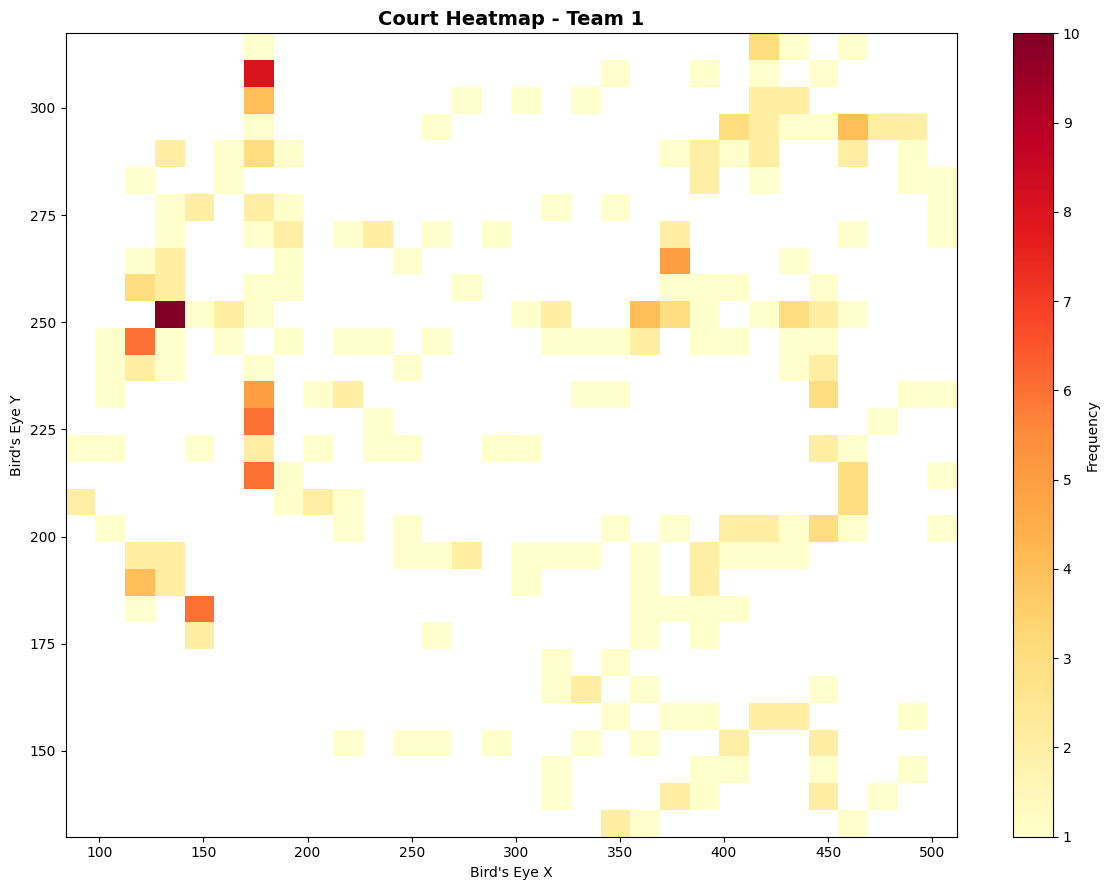

In [ ]:
def plot_court_heatmap(df, player_id=None, team_id=None):
    """Plot a heatmap of player positions on the bird's eye view court."""
    if df.empty:
        print("Cannot plot heatmap - empty DataFrame")
        return

    plot_df = df.copy()
    if player_id is not None:
        plot_df = plot_df[plot_df['playerId'] == player_id]
    if team_id is not None:
        plot_df = plot_df[plot_df['teamId'] == team_id]

    if plot_df.empty:
        print("No data to plot with specified filters")
        return

    if 'birdEyeX' in plot_df.columns and 'birdEyeY' in plot_df.columns:
        x = plot_df['birdEyeX'].values
        y = plot_df['birdEyeY'].values
    else:
        print("No bird's eye coordinates found")
        return

    fig, ax = plt.subplots(figsize=(12, 9))
    h = ax.hist2d(x, y, bins=30, cmap='YlOrRd', cmin=1)

    title = "Court Heatmap"
    if player_id is not None:
        title += f" - Player {player_id}"
    if team_id is not None:
        title += f" - Team {team_id}"

    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Bird\'s Eye X')
    ax.set_ylabel('Bird\'s Eye Y')
    plt.colorbar(h[3], ax=ax, label='Frequency')
    plt.tight_layout()
    plt.show()

def plot_speed_over_time(df, player_id):
    """Plot speed over time for a specific player."""
    player_data = df[df['playerId'] == player_id].sort_values('frame')

    if len(player_data) < 2:
        print(f"Not enough data for player {player_id}")
        return

    x = player_data['x'].values
    y = player_data['y'].values
    timestamps = player_data['timestamp'].values

    dx = np.diff(x)
    dy = np.diff(y)
    distances = np.sqrt(dx**2 + dy**2)
    time_deltas = np.diff(timestamps)
    time_deltas = np.where(time_deltas == 0, 1e-6, time_deltas)
    speeds = distances / time_deltas

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(timestamps[:-1], speeds, linewidth=1.5, color='steelblue')
    ax.set_xlabel('Timestamp (s)')
    ax.set_ylabel('Speed (pixels/s)')
    ax.set_title(f'Speed Over Time - Player {player_id}')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_zone_distribution(df, player_id=None, team_id=None):
    """Plot zone distribution for a player or team."""
    plot_df = df.copy()
    if player_id is not None:
        plot_df = plot_df[plot_df['playerId'] == player_id]
    if team_id is not None:
        plot_df = plot_df[plot_df['teamId'] == team_id]

    if plot_df.empty or 'zone' not in plot_df.columns:
        print("No zone data to plot")
        return

    zone_counts = plot_df['zone'].value_counts().sort_index()
    zone_names = {0: 'Outside', 1: 'Right 3pt', 2: 'Right 2pt', 3: 'Left 3pt', 4: 'Left 2pt'}

    fig, ax = plt.subplots(figsize=(10, 6))
    zones = [zone_names.get(z, f'Zone {z}') for z in zone_counts.index]
    ax.bar(zones, zone_counts.values, color='steelblue', alpha=0.7, edgecolor='black')
    ax.set_ylabel('Frame Count')
    ax.set_title('Zone Distribution')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

print("Visualization functions defined.")

plot_court_heatmap(tracking_df, team_id=1)  # plot heatmap for team 1

---

## 8. Hustle Index & Player Leaderboard


PLAYER HUSTLE LEADERBOARD
 playerId  teamId  total_distance_camera  avg_speed_camera  max_speed_camera  hustle_index
       25      -1                5819.22            256.63           2829.70          1.87
       17       2                4964.88            158.82            710.12          0.61
       16       2                5014.23            155.14            658.99          0.60
       19       2                3993.92            150.18           1407.30          0.49
       18       1                4981.43            148.20            374.37          0.48
       20       1                4339.16            141.51            390.37          0.28
       12       1                3967.31            129.35            401.98          0.12
       15       1                3873.52            127.05            321.39          0.06
       21       1                3849.94            122.26            302.66          0.03
       14       2                2575.42             98.61     

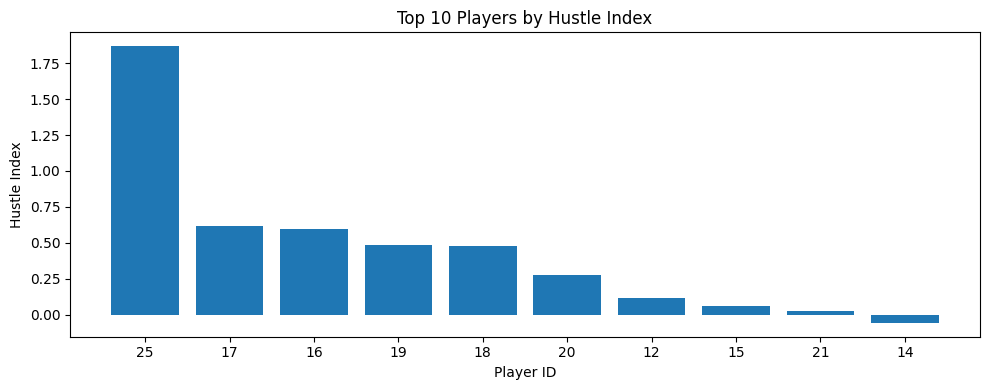

In [11]:
def add_hustle_index(speed_df):
    """Add z-scored features and a composite 'hustle_index' per player.
    
    HustleIndex = 0.5*z(total_distance) + 0.3*z(avg_speed) + 0.2*z(max_speed)
    """
    df = speed_df.copy()

    feature_cols = [
        'total_distance_camera',
        'avg_speed_camera',
        'max_speed_camera'
    ]

    # compute z-scores safely
    for col in feature_cols:
        mu = df[col].mean()
        sigma = df[col].std()
        z_col = col + '_z'

        if sigma == 0 or np.isnan(sigma):
            df[z_col] = 0.0
        else:
            df[z_col] = (df[col] - mu) / sigma

    # weighted combination -> hustle index
    df['hustle_index'] = (
        0.5 * df['total_distance_camera_z'] +
        0.3 * df['avg_speed_camera_z'] +
        0.2 * df['max_speed_camera_z']
    )

    return df

speed_hustle = add_hustle_index(speed_metrics)
hustle_ranked = speed_hustle.sort_values('hustle_index', ascending=False)

print("\n" + "="*80)
print("PLAYER HUSTLE LEADERBOARD")
print("="*80)
print(
    hustle_ranked[[
        'playerId',
        'teamId',
        'total_distance_camera',
        'avg_speed_camera',
        'max_speed_camera',
        'hustle_index'
    ]].to_string(index=False, float_format=lambda x: f"{x:8.2f}")
)

# Bar chart of top N hustlers
top_n = 10 if len(hustle_ranked) > 10 else len(hustle_ranked)
top_hustlers = hustle_ranked.head(top_n)

plt.figure(figsize=(10, 4))
plt.bar(
    top_hustlers['playerId'].astype(str),
    top_hustlers['hustle_index']
)
plt.xlabel("Player ID")
plt.ylabel("Hustle Index")
plt.title(f"Top {top_n} Players by Hustle Index")
plt.tight_layout()
plt.show()

---

## 9. Player Role Classification & Zone Profiles


PLAYER ROLE CLASSIFICATION


,playerId,teamId,role_label,most_common_zone_name,zone_transitions
0,8,0,Transition / outside,Outside,0
1,12,1,Perimeter / 3pt wing,Right 3pt,6
2,13,2,Inside scorer / high-post,Right 2pt,9
3,14,2,Inside scorer / high-post,Right 2pt,8
4,16,2,Inside scorer / high-post,Right 2pt,8
5,17,2,Inside scorer / high-post,Right 2pt,8
6,25,-1,Baseline / cutter,Outside,18
7,15,1,Perimeter / 3pt wing,Right 3pt,8
8,18,1,Inside scorer / high-post,Left 2pt,9
9,21,1,Inside scorer / high-post,Right 2pt,5



EXAMPLE PLAYER & TEAM ZONE PROFILES


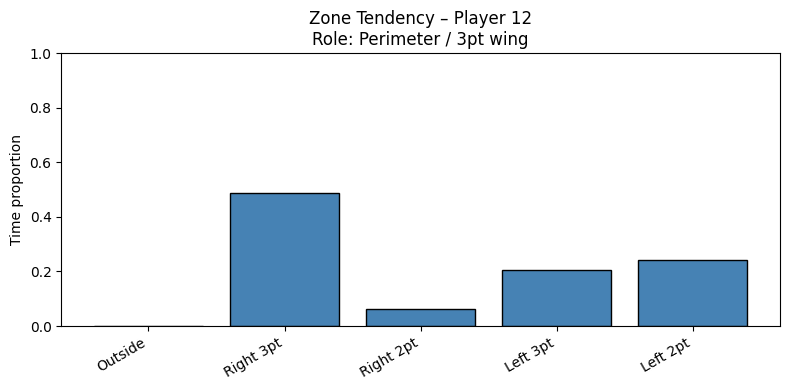

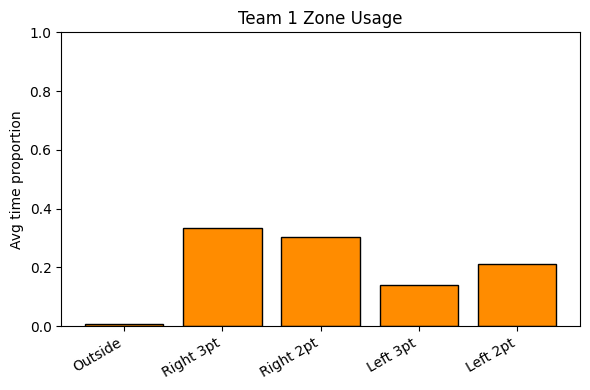

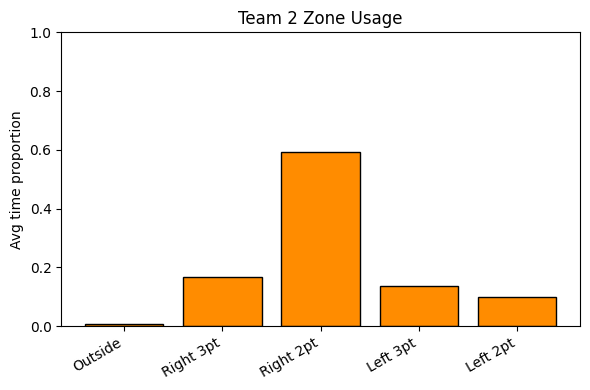

In [ ]:
# Ensure zone_metrics exists
zone_metrics = compute_zone_metrics(tracking_df)

# keep only players with enough data
min_frames = 10
valid_players = tracking_df.groupby('playerId')['frame'].count()
valid_players = valid_players[valid_players >= min_frames].index

zone_metrics = zone_metrics[zone_metrics['playerId'].isin(valid_players)].reset_index(drop=True)

# Build per-player zone time vector
zone_cols_time = [f'zone_{z}_time_sec' for z in range(5)]
zone_cols_count = [f'zone_{z}_count' for z in range(5)]

# Normalize time per player to get proportions
zone_metrics['total_zone_time'] = zone_metrics[zone_cols_time].sum(axis=1)
for z in range(5):
    col = f'zone_{z}_time_sec'
    zone_metrics[f'zone_{z}_time_prop'] = np.where(
        zone_metrics['total_zone_time'] > 0,
        zone_metrics[col] / zone_metrics['total_zone_time'],
        0.0
    )

def classify_role(row):
    """Classify player role based on zone usage patterns."""
    z0 = row['zone_0_time_prop']  # Outside
    z1 = row['zone_1_time_prop']  # Right 3pt
    z2 = row['zone_2_time_prop']  # Right 2pt
    z3 = row['zone_3_time_prop']  # Left 3pt
    z4 = row['zone_4_time_prop']  # Left 2pt

    three_prop = z1 + z3
    two_prop = z2 + z4

    if three_prop > 0.5:
        return 'Perimeter / 3pt wing'
    if z0 > 0.5:
        return 'Transition / outside'
    if two_prop > 0.5:
        return 'Inside scorer / high-post'
    if row['zone_transitions'] >= 10:
        return 'Baseline / cutter'
    return 'Mixed role'

zone_metrics['role_label'] = zone_metrics.apply(classify_role, axis=1)

zone_summary = zone_metrics[['playerId', 'teamId', 'role_label', 'most_common_zone_name', 'zone_transitions']]

print("\n" + "="*80)
print("PLAYER ROLE CLASSIFICATION")
print("="*80)
display(zone_summary)

zone_name_map = {0: 'Outside', 1: 'Right 3pt', 2: 'Right 2pt', 3: 'Left 3pt', 4: 'Left 2pt'}

def plot_player_zone_profile(player_id):
    """Visualize zone tendencies for a single player."""
    row = zone_metrics[zone_metrics['playerId'] == player_id]
    if row.empty:
        print(f"No zone data for player {player_id}")
        return

    row = row.iloc[0]
    props = [row[f'zone_{z}_time_prop'] for z in range(5)]
    labels = [zone_name_map[z] for z in range(5)]

    plt.figure(figsize=(8, 4))
    plt.bar(labels, props, color='steelblue', edgecolor='black')
    plt.ylim(0, 1)
    plt.ylabel('Time proportion')
    plt.title(f'Zone Tendency – Player {player_id}\nRole: {row["role_label"]}')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

def plot_team_zone_profile(team_id):
    """Visualize average zone usage for a team."""
    team_z = zone_metrics[zone_metrics['teamId'] == team_id]
    if team_z.empty:
        print(f"No zone data for team {team_id}")
        return

    # team-average zone proportions
    team_props = []
    labels = [zone_name_map[z] for z in range(5)]
    for z in range(5):
        team_props.append(team_z[f'zone_{z}_time_prop'].mean())

    plt.figure(figsize=(6, 4))
    plt.bar(labels, team_props, color='darkorange', edgecolor='black')
    plt.ylim(0, 1)
    plt.ylabel('Avg time proportion')
    plt.title(f'Team {team_id} Zone Usage')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

print("\n" + "="*80)
print("EXAMPLE PLAYER & TEAM ZONE PROFILES")
print("="*80)
plot_player_zone_profile(player_id=12)
plot_team_zone_profile(team_id=1)
plot_team_zone_profile(team_id=2)

---

## 10. Zone Transition Analysis

In [ ]:
# Build overall zone transition matrix 
zones_list = list(range(5))
transition_matrix = pd.DataFrame(
    0, index=zones_list, columns=zones_list, dtype=int
)

for pid in tracking_df['playerId'].dropna().unique():
    p = tracking_df[tracking_df['playerId'] == pid].sort_values('frame')
    if 'zone' not in p.columns or len(p) < 2:
        continue
    z = p['zone'].to_numpy()
    z_from = z[:-1]
    z_to = z[1:]
    for a, b in zip(z_from, z_to):
        if a in zones_list and b in zones_list:
            transition_matrix.loc[a, b] += 1

print("\n" + "="*80)
print("ZONE TRANSITION MATRIX")
print("="*80)
display(transition_matrix)


ZONE TRANSITION MATRIX


,0,1,2,3,4
0,47,2,0,0,7
1,2,132,13,8,0
2,1,12,247,0,0
3,0,10,0,91,15
4,5,1,0,18,154


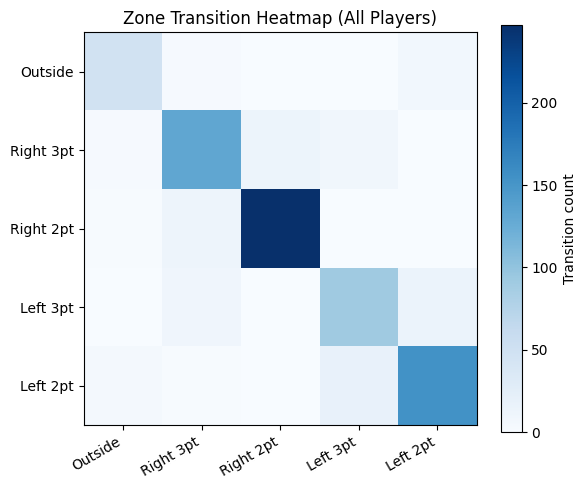

In [14]:
# Visualize zone transitions as heatmap
zone_name_map = {0: 'Outside', 1: 'Right 3pt', 2: 'Right 2pt',
                 3: 'Left 3pt', 4: 'Left 2pt'}

plt.figure(figsize=(6, 5))
plt.imshow(transition_matrix, cmap='Blues')
plt.colorbar(label='Transition count')
plt.xticks(ticks=zones_list, labels=[zone_name_map[z] for z in zones_list], rotation=30, ha='right')
plt.yticks(ticks=zones_list, labels=[zone_name_map[z] for z in zones_list])
plt.title('Zone Transition Heatmap (All Players)')
plt.tight_layout()
plt.show()